In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv('../data/marketing_AB.csv')
print(df.head())
print(df.info())
print(df.value_counts())
print('sum of duplicates',df.duplicated('user id').sum())
df

   Unnamed: 0  user id test group  converted  total ads most ads day  \
0           0  1069124         ad      False        130       Monday   
1           1  1119715         ad      False         93      Tuesday   
2           2  1144181         ad      False         21      Tuesday   
3           3  1435133         ad      False        355      Tuesday   
4           4  1015700         ad      False        276       Friday   

   most ads hour  
0             20  
1             22  
2             18  
3             10  
4             14  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   Unnamed: 0     588101 non-null  int64 
 1   user id        588101 non-null  int64 
 2   test group     588101 non-null  object
 3   converted      588101 non-null  bool  
 4   total ads      588101 non-null  int64 
 5   most ads day   588101 non-null

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14
...,...,...,...,...,...,...,...
588096,588096,1278437,ad,False,1,Tuesday,23
588097,588097,1327975,ad,False,1,Tuesday,23
588098,588098,1038442,ad,False,3,Tuesday,23
588099,588099,1496395,ad,False,1,Tuesday,23


In [17]:
df.drop(columns=["Unnamed: 0"],inplace=True)
df.rename(columns={"user id":"user_id","test group":"test_group"},inplace=True)


In [18]:
print('test group value count' ,df['test_group'].value_counts())
print('mean converted ' , df['converted'].mean())
print(df.groupby('test_group')['converted'].mean())

test group value count test_group
ad     564577
psa     23524
Name: count, dtype: int64
mean converted  0.02523886203220195
test_group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64


In [19]:
df.groupby('test_group')['converted'].mean()

test_group
ad     0.025547
psa    0.017854
Name: converted, dtype: float64

In [20]:
df.columns

Index(['user_id', 'test_group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [21]:
df.groupby('most ads day')['converted'].mean().sort_values(ascending=False)

most ads day
Monday       0.032812
Tuesday      0.029840
Wednesday    0.024942
Sunday       0.024476
Friday       0.022212
Thursday     0.021571
Saturday     0.021051
Name: converted, dtype: float64

<Axes: xlabel='most ads hour'>

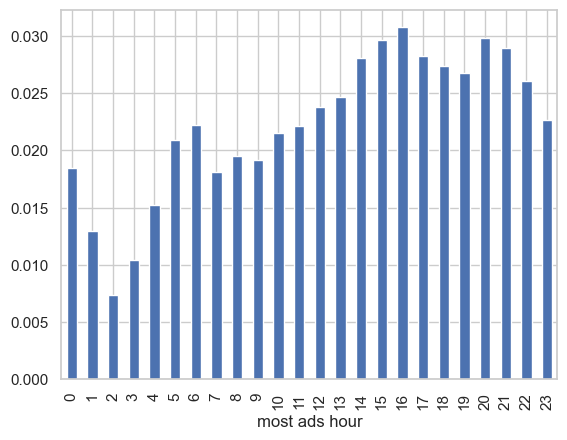

In [22]:
df.groupby('most ads hour')['converted'].mean().plot(kind='bar')

<Axes: xlabel='converted', ylabel='total ads'>

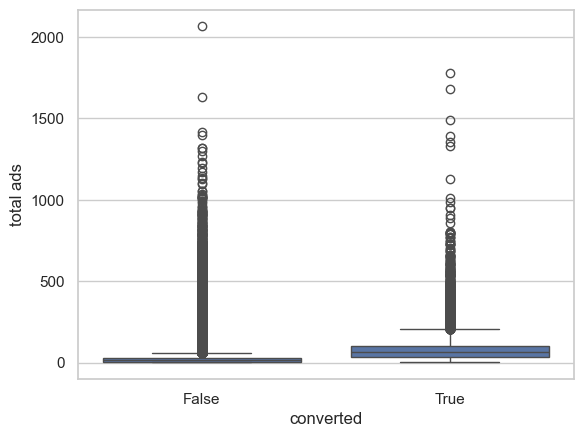

In [23]:
sns.boxplot(data=df, x='converted', y='total ads')


In [24]:
convert_ad = df[df['test_group'] == 'ad']['converted'].sum()
convert_psa = df[df['test_group'] == 'psa']['converted'].sum()

n_ad = df[df['test_group'] == 'ad'].shape[0]
n_psa = df[df['test_group'] == 'psa'].shape[0]

print(f"Ad converted: {convert_ad}, Total Ad: {n_ad}")
print(f"PSA converted: {convert_psa}, Total PSA: {n_psa}")

Ad converted: 14423, Total Ad: 564577
PSA converted: 420, Total PSA: 23524


*** start The Z-Test *** 

In [25]:
from statsmodels.stats.proportion import proportions_ztest
# people who has acually bought in both ads vs psa
count = [convert_ad, convert_psa]
# has total per each in count ads vs psa  
nobs = [n_ad, n_psa]
#star the test  
z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print(f'Z-statistic: {z_stat:.4f}')
print(f'P-value: {p_value:.10f}')

Z-statistic: 7.3701
P-value: 0.0000000000


C:\Users\Right Click\AppData\Local\Temp\ipykernel_3864\1573896889.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conv_rates.index, y=conv_rates.values, ax=axes[0], palette=colors)


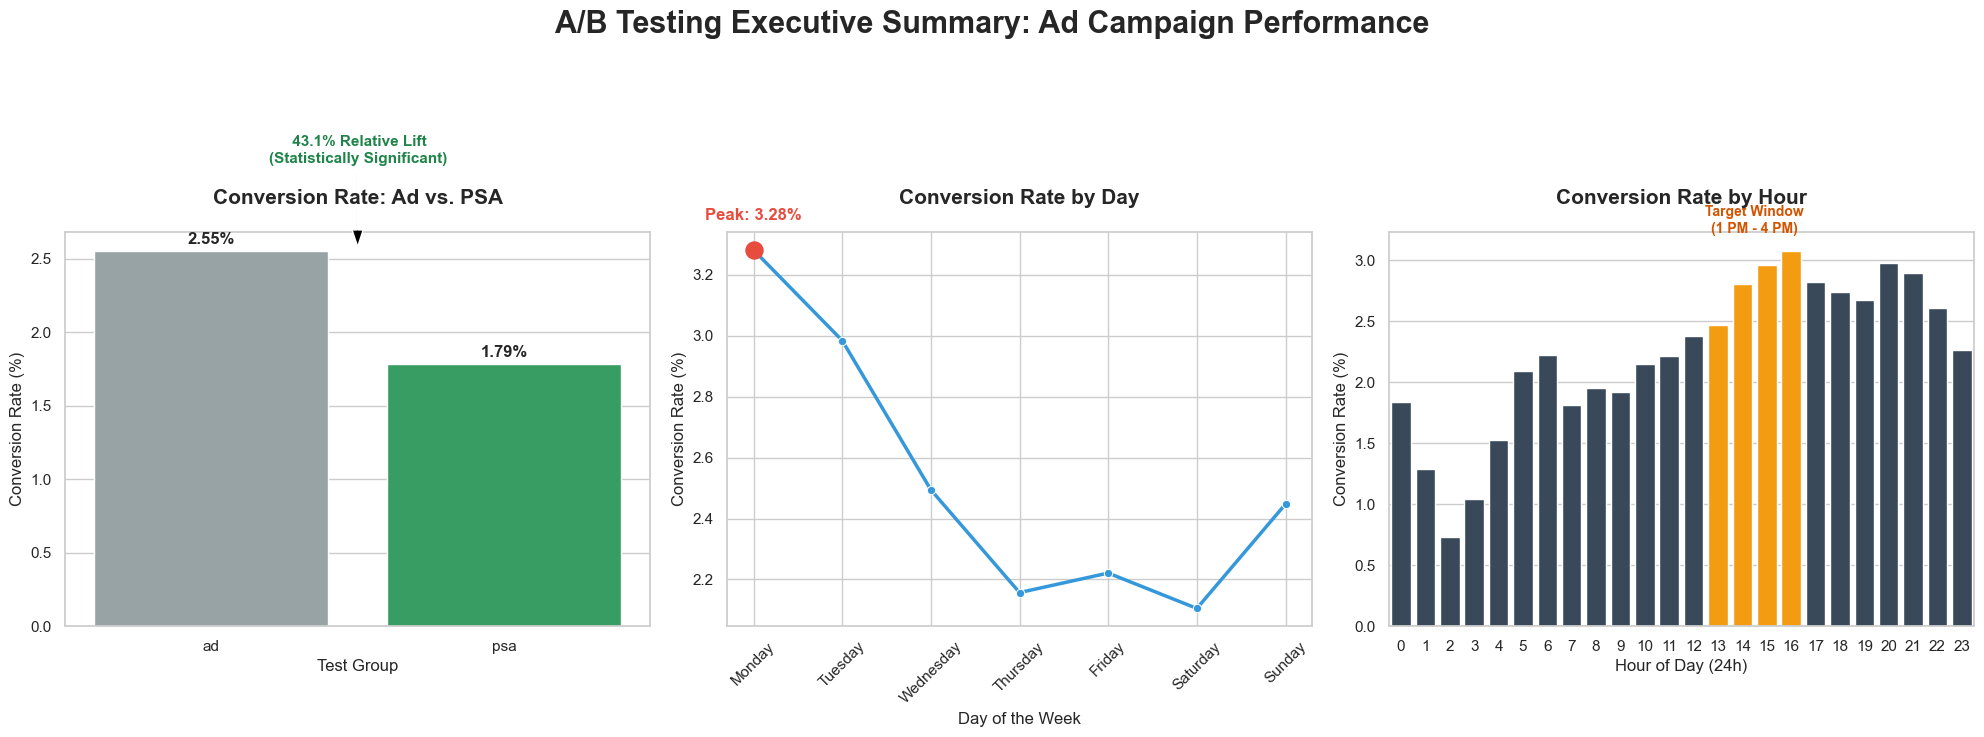

In [26]:
# Setting a clean style
sns.set_theme(style="whitegrid")

# --- 1. Dashboard Layout ---
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 7))
plt.subplots_adjust(wspace=0.3)

# --- 2. Conversion Rate Comparison (Left) ---
conv_rates = df.groupby('test_group')['converted'].mean() * 100
colors = ['#95a5a6', '#27ae60'] # Grey for PSA, Green for Ad

sns.barplot(x=conv_rates.index, y=conv_rates.values, ax=axes[0], palette=colors)
axes[0].set_title('Conversion Rate: Ad vs. PSA', fontsize=15, fontweight='bold', pad=20)
axes[0].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[0].set_xlabel('Test Group', fontsize=12)

# Adding percentages on top of bars
for i, v in enumerate(conv_rates.values):
    axes[0].text(i, v + 0.05, f"{v:.2f}%", ha='center', fontweight='bold', size=12)

# Adding the "Lift" annotation
lift = ((conv_rates['ad'] - conv_rates['psa']) / conv_rates['psa']) * 100
axes[0].annotate(f' {lift:.1f}% Relative Lift\n(Statistically Significant)', 
                 xy=(0.5, conv_rates['ad']), xytext=(0.5, conv_rates['ad'] + 0.6),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
                 ha='center', fontsize=11, color='#1e8449', fontweight='bold')


# --- 3. Conversion by Day of Week (Middle) ---
day_conv = df.groupby('most ads day')['converted'].mean() * 100
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_conv = day_conv.reindex(days_order)

sns.lineplot(x=day_conv.index, y=day_conv.values, marker='o', color='#3498db', linewidth=2.5, ax=axes[1])
axes[1].set_title('Conversion Rate by Day', fontsize=15, fontweight='bold', pad=20)
axes[1].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[1].set_xlabel('Day of the Week', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Highlighting Monday (The Peak)
peak_day = 'Monday'
peak_val = day_conv['Monday']
axes[1].scatter(peak_day, peak_val, color='#e74c3c', s=150, zorder=5)
axes[1].text(peak_day, peak_val + 0.1, f"Peak: {peak_val:.2f}%", color='#e74c3c', fontweight='bold', ha='center')


# --- 4. Conversion by Hour (Right) ---
hour_conv = df.groupby('most ads hour')['converted'].mean() * 100

sns.barplot(x=hour_conv.index, y=hour_conv.values, color='#34495e', ax=axes[2])
axes[2].set_title('Conversion Rate by Hour', fontsize=15, fontweight='bold', pad=20)
axes[2].set_ylabel('Conversion Rate (%)', fontsize=12)
axes[2].set_xlabel('Hour of Day (24h)', fontsize=12)

# Highlighting Peak Hours (13-16)
for hour in range(13, 17):
    axes[2].patches[hour].set_facecolor('#f39c12')

axes[2].text(14.5, hour_conv.max() + 0.15, "Target Window\n(1 PM - 4 PM)", 
             ha='center', color='#d35400', fontweight='bold', fontsize=10)


# --- 5. Final Touch ---
plt.suptitle('A/B Testing Executive Summary: Ad Campaign Performance', fontsize=22, fontweight='bold', y=1.05)
plt.tight_layout()

# Save the clean English version
plt.savefig('ab_test_english_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()